<a href="https://colab.research.google.com/github/mokhivibes/ml_course_hometasks/blob/main/6_Homework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install opendatasets

In [2]:
import opendatasets as od
od.download("https://www.kaggle.com/datasets/sukhmandeepsinghbrar/car-price-prediction-dataset/data")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: mokhivibes
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/sukhmandeepsinghbrar/car-price-prediction-dataset


100%|██████████| 141k/141k [00:00<00:00, 352kB/s]

In [3]:
import pandas as pd
df = pd.read_csv("/content/car-price-prediction-dataset/cardekho.csv")

In [4]:
#1-step=> check how many rows and columns in our data
df.shape

(8128, 12)

In [5]:
#2-step=> check what kind of data is stored in each column
df.head(20)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78,5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.2,5.0
5,Hyundai Xcent 1.2 VTVT E Plus,2017,440000,45000,Petrol,Individual,Manual,First Owner,20.14,1197.0,81.86,5.0
6,Maruti Wagon R LXI DUO BSIII,2007,96000,175000,LPG,Individual,Manual,First Owner,17.30,1061.0,57.5,5.0
7,Maruti 800 DX BSII,2001,45000,5000,Petrol,Individual,Manual,Second Owner,16.10,796.0,37,4.0
8,Toyota Etios VXD,2011,350000,90000,Diesel,Individual,Manual,First Owner,23.59,1364.0,67.1,5.0
9,Ford Figo Diesel Celebration Edition,2013,200000,169000,Diesel,Individual,Manual,First Owner,20.00,1399.0,68.1,5.0


In [6]:
#3-step=> Read the column names and understand what each column represents
df.columns


Index(['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner', 'mileage(km/ltr/kg)', 'engine', 'max_power',
       'seats'],
      dtype='object')

In [7]:
#4-step=> Check the data types of each column (numbers, text, dates, etc.)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                8128 non-null   object 
 1   year                8128 non-null   int64  
 2   selling_price       8128 non-null   int64  
 3   km_driven           8128 non-null   int64  
 4   fuel                8128 non-null   object 
 5   seller_type         8128 non-null   object 
 6   transmission        8128 non-null   object 
 7   owner               8128 non-null   object 
 8   mileage(km/ltr/kg)  7907 non-null   float64
 9   engine              7907 non-null   float64
 10  max_power           7913 non-null   object 
 11  seats               7907 non-null   float64
dtypes: float64(3), int64(3), object(6)
memory usage: 762.1+ KB


In [8]:
#5-step => Count how many null/missing values exist in each column
df.isnull().sum().sort_values(ascending=False).head(20)


,0
seats,221
mileage(km/ltr/kg),221
engine,221
max_power,215
km_driven,0
selling_price,0
year,0
name,0
owner,0
transmission,0


In [9]:
missing = (df.isnull().sum() / len(df) * 100).round(2)
missing[missing >0].sort_values(ascending=False)
missing[missing >0].sort_values(ascending=False)


,0
mileage(km/ltr/kg),2.72
engine,2.72
seats,2.72
max_power,2.65


In [10]:
df.drop('seats', axis=1)
number_column_list = ['mileage(km/ltr/kg)', 'engine', 'max_power']
df[number_column_list].info()
import numpy as np

df['max_power'] = df['max_power'].replace(' ', np.nan).astype(float)
df[number_column_list] = df[number_column_list].fillna(df[number_column_list].mean())
df[number_column_list].isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   mileage(km/ltr/kg)  7907 non-null   float64
 1   engine              7907 non-null   float64
 2   max_power           7913 non-null   object 
dtypes: float64(2), object(1)
memory usage: 190.6+ KB


,0
mileage(km/ltr/kg),0
engine,0
max_power,0


In [11]:
print(df.duplicated().sum())
df.drop_duplicates(keep='first', inplace=True)
df.shape

1202


(6926, 12)

In [12]:
df.isnull().sum()

,0
name,0
year,0
selling_price,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0
mileage(km/ltr/kg),0
engine,0


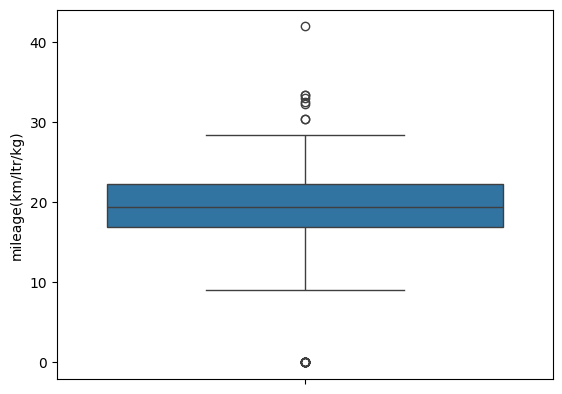

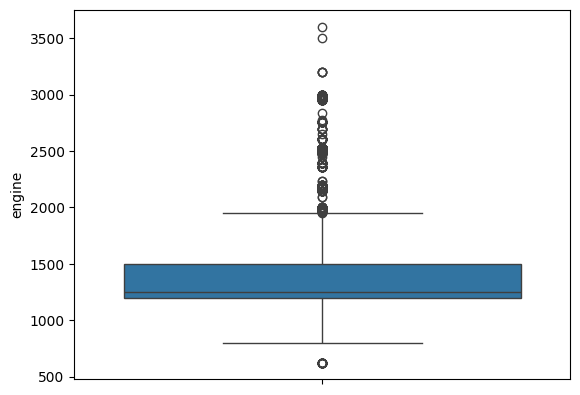

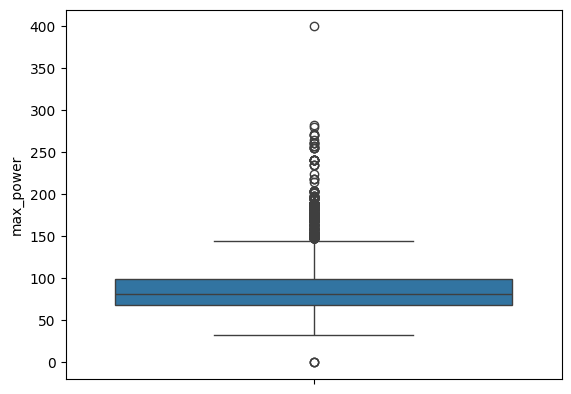

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

for column in df[number_column_list]:
  sns.boxplot(data = df, y=column)
  plt.show()

In [15]:
df_clean = df.copy()
for column in number_column_list:
  Q1= df[column].quantile(0.25)
  print(Q1)
  Q3= df[column].quantile(0.75)
  print(Q3)
  IQR = Q3-Q1

  #Outlier filtr

  mask = (df[column] <= (Q3+1.5*IQR)) & \
       (df[column] >= (Q1-1.5*IQR))
  df_clean= df_clean[mask]


16.95
22.32
1197.0
1498.0
68.0
99.0


/tmp/ipykernel_9001/1696566331.py:13: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_clean= df_clean[mask]
/tmp/ipykernel_9001/1696566331.py:13: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_clean= df_clean[mask]


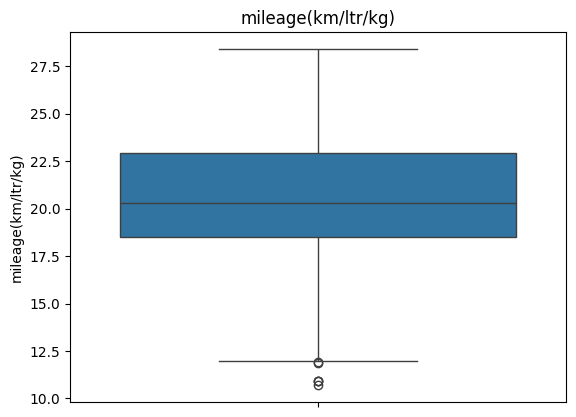

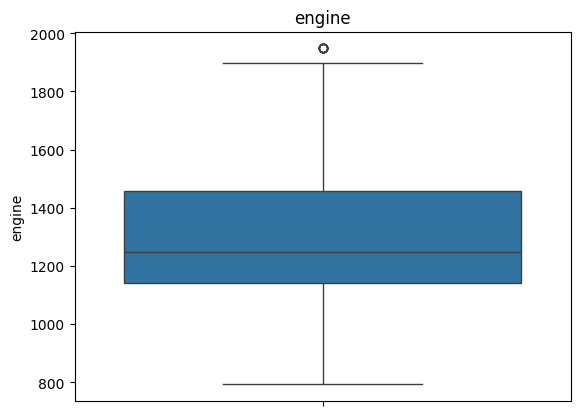

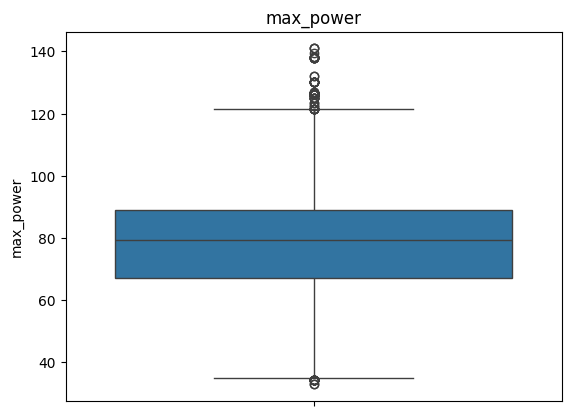

In [16]:
for column in number_column_list:
  sns.boxplot(data = df_clean, y=column)
  plt.title(column)
  plt.show()

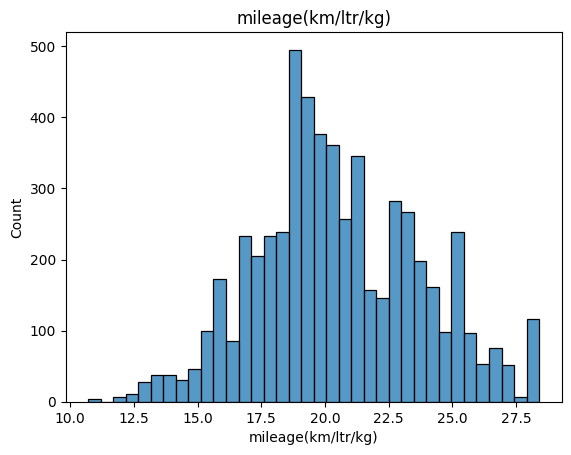

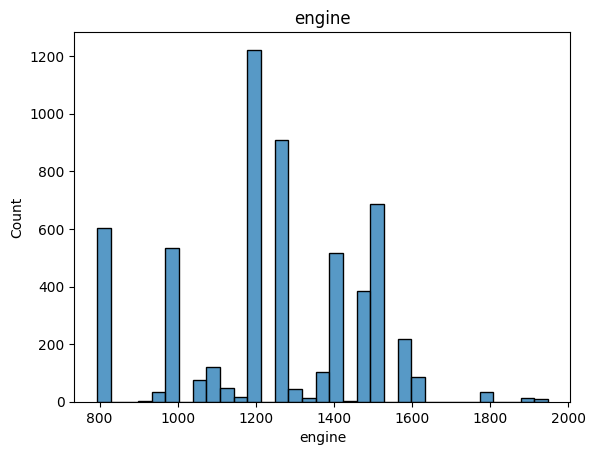

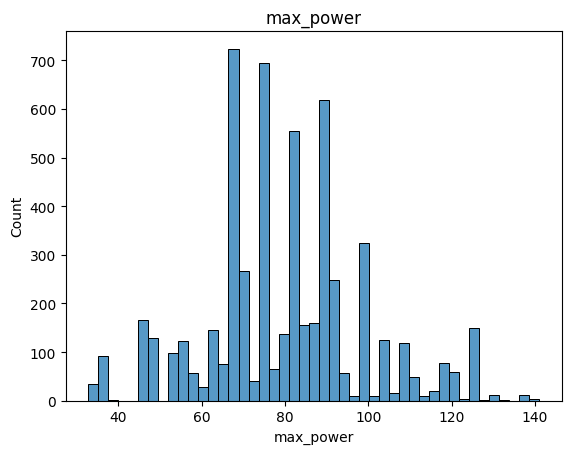

In [17]:
for column in number_column_list:
  sns.histplot(data = df_clean, x=column)
  plt.title(column)
  plt.show()

In [18]:
df_clean.describe()

,year,selling_price,km_driven,mileage(km/ltr/kg),engine,max_power,seats
count,5676.000000,5.676000e+03,5.676000e+03,5676.000000,5676.000000,5676.000000,5471.000000
mean,2013.470049,4.171575e+05,6.891430e+04,20.541491,1241.856083,79.765394,5.138366
std,4.184467,2.523952e+05,5.273654e+04,3.230786,229.116372,19.231041,0.593114
min,1983.000000,2.999900e+04,1.000000e+00,10.710000,793.000000,32.800000,4.000000
25%,2011.000000,2.200000e+05,3.500000e+04,18.500000,1142.500000,67.100000,5.000000
50%,2014.000000,3.700000e+05,6.000000e+04,20.300000,1248.000000,79.400000,5.000000
75%,2017.000000,5.750000e+05,9.265975e+04,22.900000,1458.625016,88.800000,5.000000
max,2020.000000,2.150000e+06,2.360457e+06,28.400000,1948.000000,141.000000,14.000000


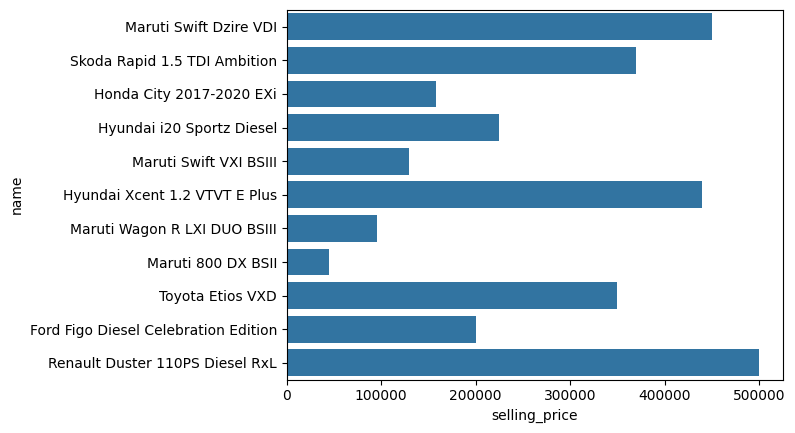

In [19]:
df_top10 = df_clean.head(11)
sns.barplot(data=df_top10, x='selling_price', y= 'name')
plt.show()

In [20]:
df_clean.describe()

,year,selling_price,km_driven,mileage(km/ltr/kg),engine,max_power,seats
count,5676.000000,5.676000e+03,5.676000e+03,5676.000000,5676.000000,5676.000000,5471.000000
mean,2013.470049,4.171575e+05,6.891430e+04,20.541491,1241.856083,79.765394,5.138366
std,4.184467,2.523952e+05,5.273654e+04,3.230786,229.116372,19.231041,0.593114
min,1983.000000,2.999900e+04,1.000000e+00,10.710000,793.000000,32.800000,4.000000
25%,2011.000000,2.200000e+05,3.500000e+04,18.500000,1142.500000,67.100000,5.000000
50%,2014.000000,3.700000e+05,6.000000e+04,20.300000,1248.000000,79.400000,5.000000
75%,2017.000000,5.750000e+05,9.265975e+04,22.900000,1458.625016,88.800000,5.000000
max,2020.000000,2.150000e+06,2.360457e+06,28.400000,1948.000000,141.000000,14.000000
